In [1]:
"""
# 04 · Training Loop Basics en PyTorch
En este notebook vamos a reorganizar el entrenamiento de un modelo en PyTorch usando funciones reutilizables.
En notebooks anteriores escribimos el entrenamiento directamente dentro de una celda. Eso está bien para aprender, 
pero en proyectos más grandes conviene separar el código en bloques más claros.
## Objetivo
Construir un pipeline de entrenamiento más ordenado usando funciones para:
- entrenar una época,
- evaluar el modelo,
- guardar métricas,
- visualizar curvas,
- guardar y cargar modelos.
Este patrón es la base para proyectos más complejos como CNNs, segmentación y modelos 3D.
"""

'\n# 04 · Training Loop Basics en PyTorch\nEn este notebook vamos a reorganizar el entrenamiento de un modelo en PyTorch usando funciones reutilizables.\nEn notebooks anteriores escribimos el entrenamiento directamente dentro de una celda. Eso está bien para aprender, \npero en proyectos más grandes conviene separar el código en bloques más claros.\n## Objetivo\nConstruir un pipeline de entrenamiento más ordenado usando funciones para:\n- entrenar una época,\n- evaluar el modelo,\n- guardar métricas,\n- visualizar curvas,\n- guardar y cargar modelos.\nEste patrón es la base para proyectos más complejos como CNNs, segmentación y modelos 3D.\n'

In [2]:
# ------------------------------------------------------------
# 01 · Imports and configuration
# ------------------------------------------------------------

from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from torch.utils.data import TensorDataset, DataLoader

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = NOTEBOOK_DIR.parent

FIGURES_DIR = PROJECT_DIR / "figures"
MODELS_DIR = PROJECT_DIR / "models"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("Selected device:", device)

PyTorch version: 2.10.0+cpu
Selected device: cpu


In [3]:
"""
## 1. Preparación del dataset
Usaremos nuevamente el dataset "digits".
La diferencia principal con el notebook anterior es que ahora vamos a dividir los datos en:
- entrenamiento,
- validación,
- test.
La validación se usa para monitorear el comportamiento del modelo durante el entrenamiento.
"""

'\n## 1. Preparación del dataset\nUsaremos nuevamente el dataset "digits".\nLa diferencia principal con el notebook anterior es que ahora vamos a dividir los datos en:\n- entrenamiento,\n- validación,\n- test.\nLa validación se usa para monitorear el comportamiento del modelo durante el entrenamiento.\n'

In [4]:
# ------------------------------------------------------------
# 02 · Load and split dataset
# ------------------------------------------------------------

digits = load_digits()

X = digits.data.astype(np.float32)
y = digits.target.astype(np.int64)

# Normalize input values from approximately [0, 16] to [0, 1]
X = X / 16.0

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("Train:", X_train.shape)
print("Val  :", X_val.shape)
print("Test :", X_test.shape)

Train: (1257, 64)
Val  : (270, 64)
Test : (270, 64)


In [5]:
# ------------------------------------------------------------
# 03 · Create TensorDatasets and DataLoaders
# ------------------------------------------------------------

X_train_t = torch.from_numpy(X_train)
X_val_t   = torch.from_numpy(X_val)
X_test_t  = torch.from_numpy(X_test)

y_train_t = torch.from_numpy(y_train)
y_val_t   = torch.from_numpy(y_val)
y_test_t  = torch.from_numpy(y_test)

batch_size = 32

train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset   = TensorDataset(X_val_t, y_val_t)
test_dataset  = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Number of train batches:", len(train_loader))
print("Number of val batches  :", len(val_loader))
print("Number of test batches :", len(test_loader))

Number of train batches: 40
Number of val batches  : 9
Number of test batches : 9


In [6]:
"""
## 2. Definición del modelo
Usaremos un MLP simple, similar al notebook anterior.
La diferencia principal no está en la arquitectura, sino en cómo vamos a organizar el entrenamiento.
"""

'\n## 2. Definición del modelo\nUsaremos un MLP simple, similar al notebook anterior.\nLa diferencia principal no está en la arquitectura, sino en cómo vamos a organizar el entrenamiento.\n'

In [7]:
# ------------------------------------------------------------
# 04 · Define model
# ------------------------------------------------------------

class MLP(nn.Module):
    def __init__(self, input_dim=64, hidden_dim=128, output_dim=10):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, output_dim)
        )

    def forward(self, x):
        return self.network(x)


model = MLP().to(device)

print(model)

MLP(
  (network): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [8]:
# ------------------------------------------------------------
# 05 · Loss function and optimizer
# ------------------------------------------------------------

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [9]:
"""
## 3. Función "train_one_epoch"
Esta función realiza una época completa de entrenamiento.
Recibe:
- modelo,
- DataLoader,
- función de pérdida,
- optimizador,
- dispositivo.
Devuelve:
- pérdida promedio,
- accuracy promedio.
"""

'\n## 3. Función "train_one_epoch"\nEsta función realiza una época completa de entrenamiento.\nRecibe:\n- modelo,\n- DataLoader,\n- función de pérdida,\n- optimizador,\n- dispositivo.\nDevuelve:\n- pérdida promedio,\n- accuracy promedio.\n'

In [11]:
# ------------------------------------------------------------
# 06 · Train one epoch function
# ------------------------------------------------------------

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

        predictions = torch.argmax(logits, dim=1)
        correct += (predictions == y_batch).sum().item()
        total += y_batch.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [12]:
"""
## 4. Función "evaluate"
Esta función evalúa el modelo sin actualizar pesos.
Usa:
python
model.eval()
para desactivar el cálculo de gradientes.
torch.no_grad()
"""


'\n## 4. Función "evaluate"\nEsta función evalúa el modelo sin actualizar pesos.\nUsa:\npython\nmodel.eval()\npara desactivar el cálculo de gradientes.\ntorch.no_grad()\n'

In [14]:

## Celda 12 — Código

#python
# ------------------------------------------------------------
# 07 · Evaluation function
# ------------------------------------------------------------

def evaluate(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            running_loss += loss.item() * X_batch.size(0)

            predictions = torch.argmax(logits, dim=1)
            correct += (predictions == y_batch).sum().item()
            total += y_batch.size(0)

            all_preds.extend(predictions.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc, all_preds, all_labels

In [15]:
"""
## 5. Entrenamiento completo
Ahora el loop principal queda mucho más limpio.
La lógica compleja está encapsulada dentro de:
- "train_one_epoch()"
- "evaluate()"
Esto hace el código:
- más legible,
- más reutilizable,
- más fácil de escalar.
"""

'\n## 5. Entrenamiento completo\nAhora el loop principal queda mucho más limpio.\nLa lógica compleja está encapsulada dentro de:\n- "train_one_epoch()"\n- "evaluate()"\nEsto hace el código:\n- más legible,\n- más reutilizable,\n- más fácil de escalar.\n'

In [16]:
# ------------------------------------------------------------
# 08 · Main training loop
# ------------------------------------------------------------

n_epochs = 50

train_loss_history = []
train_acc_history = []

val_loss_history = []
val_acc_history = []

for epoch in range(n_epochs):

    # Training
    train_loss, train_acc = train_one_epoch(
        model=model,
        dataloader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    # Validation
    val_loss, val_acc, _, _ = evaluate(
        model=model,
        dataloader=val_loader,
        criterion=criterion,
        device=device
    )

    # Store metrics
    train_loss_history.append(train_loss)
    train_acc_history.append(train_acc)

    val_loss_history.append(val_loss)
    val_acc_history.append(val_acc)

    # Print progress
    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch [{epoch+1:03d}/{n_epochs}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

Epoch [010/50] | Train Loss: 0.1309 | Train Acc: 0.9714 | Val Loss: 0.1733 | Val Acc: 0.9519
Epoch [020/50] | Train Loss: 0.0543 | Train Acc: 0.9881 | Val Loss: 0.1356 | Val Acc: 0.9667
Epoch [030/50] | Train Loss: 0.0262 | Train Acc: 0.9968 | Val Loss: 0.1196 | Val Acc: 0.9741
Epoch [040/50] | Train Loss: 0.0125 | Train Acc: 1.0000 | Val Loss: 0.1192 | Val Acc: 0.9667
Epoch [050/50] | Train Loss: 0.0064 | Train Acc: 1.0000 | Val Loss: 0.1249 | Val Acc: 0.9704


In [17]:
"""
## 6. Visualización de métricas
Las curvas de entrenamiento permiten detectar:
- overfitting,
- underfitting,
- convergencia,
- problemas de entrenamiento.
"""

'\n## 6. Visualización de métricas\nLas curvas de entrenamiento permiten detectar:\n- overfitting,\n- underfitting,\n- convergencia,\n- problemas de entrenamiento.\n'

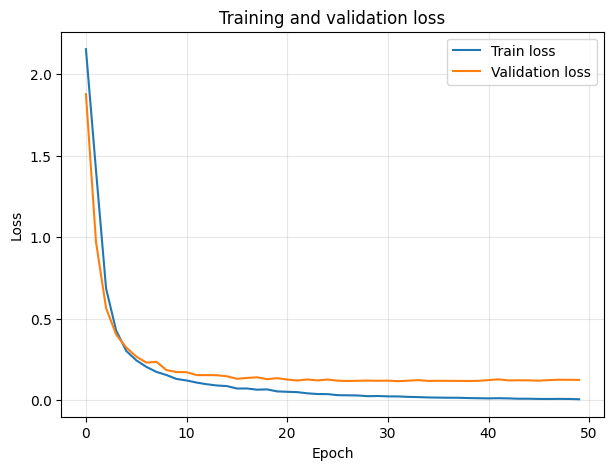

Figura guardada en: C:\Users\Peter\ai-imaging-portfolio\02_pytorch_basics\figures\training_validation_loss.png


In [18]:
# ------------------------------------------------------------
# 09 · Plot loss curves
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

plt.plot(train_loss_history, label="Train loss")
plt.plot(val_loss_history, label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and validation loss")
plt.legend()
plt.grid(alpha=0.3)

out = FIGURES_DIR / "training_validation_loss.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figura guardada en: {out}")

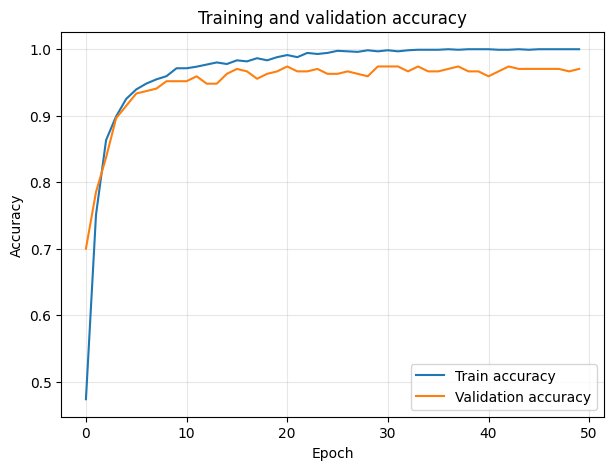

Figura guardada en: C:\Users\Peter\ai-imaging-portfolio\02_pytorch_basics\figures\training_validation_accuracy.png


In [19]:
# ------------------------------------------------------------
# 10 · Plot accuracy curves
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

plt.plot(train_acc_history, label="Train accuracy")
plt.plot(val_acc_history, label="Validation accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.grid(alpha=0.3)

out = FIGURES_DIR / "training_validation_accuracy.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figura guardada en: {out}")

In [20]:
"""
## 7. Evaluación final sobre test
El conjunto de test solo se usa al final del entrenamiento.
Esto permite medir la capacidad real de generalización del modelo.
"""

'\n## 7. Evaluación final sobre test\nEl conjunto de test solo se usa al final del entrenamiento.\nEsto permite medir la capacidad real de generalización del modelo.\n'

In [21]:
# ------------------------------------------------------------
# 11 · Final evaluation on test set
# ------------------------------------------------------------

test_loss, test_acc, test_preds, test_labels = evaluate(
    model=model,
    dataloader=test_loader,
    criterion=criterion,
    device=device
)

print(f"Test loss     : {test_loss:.4f}")
print(f"Test accuracy : {test_acc:.4f}")

Test loss     : 0.0819
Test accuracy : 0.9778


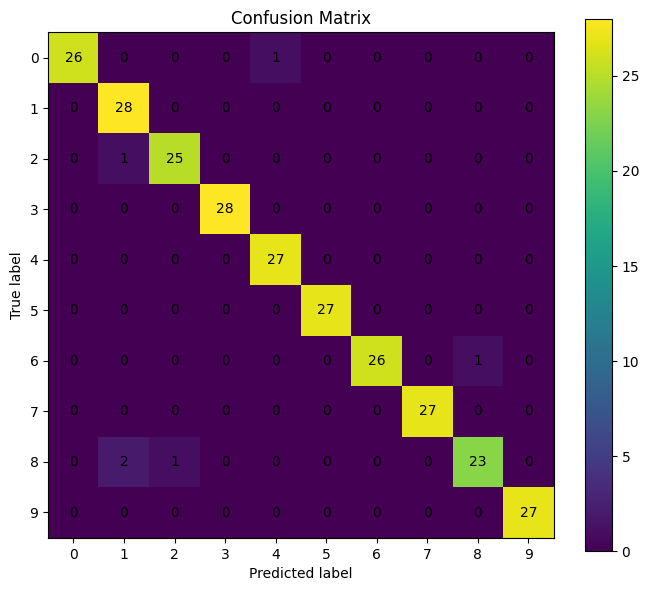

Figura guardada en: C:\Users\Peter\ai-imaging-portfolio\02_pytorch_basics\figures\final_confusion_matrix.png


In [22]:
# ------------------------------------------------------------
# 12 · Confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(7, 6))
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")

plt.colorbar()

classes = digits.target_names

plt.xticks(np.arange(len(classes)), classes)
plt.yticks(np.arange(len(classes)), classes)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()

out = FIGURES_DIR / "final_confusion_matrix.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figura guardada en: {out}")

In [23]:
# ------------------------------------------------------------
# 13 · Classification report
# ------------------------------------------------------------

report = classification_report(
    test_labels,
    test_preds,
    target_names=[str(c) for c in classes]
)

print(report)

              precision    recall  f1-score   support

           0       1.00      0.96      0.98        27
           1       0.90      1.00      0.95        28
           2       0.96      0.96      0.96        26
           3       1.00      1.00      1.00        28
           4       0.96      1.00      0.98        27
           5       1.00      1.00      1.00        27
           6       1.00      0.96      0.98        27
           7       1.00      1.00      1.00        27
           8       0.96      0.88      0.92        26
           9       1.00      1.00      1.00        27

    accuracy                           0.98       270
   macro avg       0.98      0.98      0.98       270
weighted avg       0.98      0.98      0.98       270



In [24]:
"""
## 8. Interpretación de resultados

El modelo alcanza una accuracy alta tanto en validación como en test.

Las curvas de entrenamiento muestran:

- convergencia estable,
- ausencia de overfitting fuerte,
- buena capacidad de generalización.

Este pipeline ya representa una estructura de entrenamiento reutilizable y cercana a proyectos reales.
"""

'\n## 8. Interpretación de resultados\n\nEl modelo alcanza una accuracy alta tanto en validación como en test.\n\nLas curvas de entrenamiento muestran:\n\n- convergencia estable,\n- ausencia de overfitting fuerte,\n- buena capacidad de generalización.\n\nEste pipeline ya representa una estructura de entrenamiento reutilizable y cercana a proyectos reales.\n'

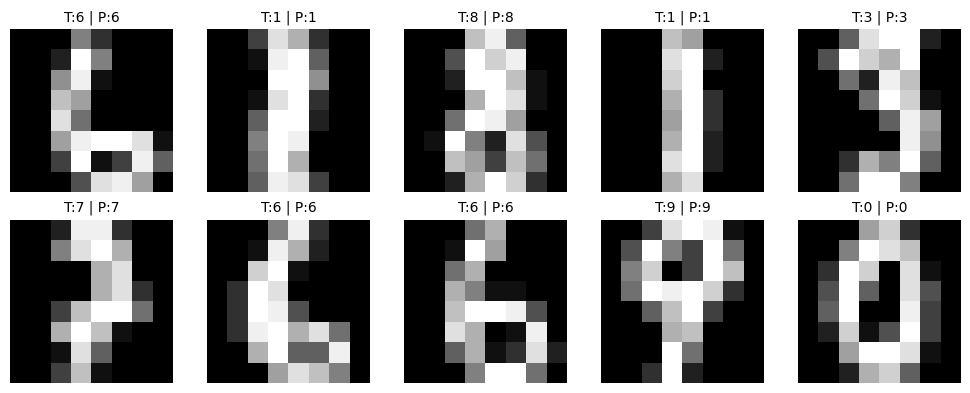

Figura guardada en: C:\Users\Peter\ai-imaging-portfolio\02_pytorch_basics\figures\training_loop_predictions.png


In [25]:
# ------------------------------------------------------------
# 14 · Visualize predictions
# ------------------------------------------------------------

model.eval()

with torch.no_grad():
    sample_logits = model(X_test_t[:10].to(device))
    sample_preds = torch.argmax(sample_logits, dim=1).cpu().numpy()

sample_images = X_test[:10]
sample_labels = y_test[:10]

fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flat):
    ax.imshow(sample_images[i].reshape(8, 8), cmap="gray")

    ax.set_title(
        f"T:{sample_labels[i]} | P:{sample_preds[i]}",
        fontsize=10
    )

    ax.axis("off")

plt.tight_layout()

out = FIGURES_DIR / "training_loop_predictions.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figura guardada en: {out}")

In [26]:
# ------------------------------------------------------------
# 15 · Save trained model
# ------------------------------------------------------------

model_path = MODELS_DIR / "training_loop_mlp_model.pt"

torch.save(model.state_dict(), model_path)

print(f"Modelo guardado en: {model_path}")

Modelo guardado en: C:\Users\Peter\ai-imaging-portfolio\02_pytorch_basics\models\training_loop_mlp_model.pt


In [27]:
"""
# Conclusión final

En este notebook construimos un pipeline de entrenamiento más profesional y reutilizable.

Implementamos:

- funciones separadas para entrenamiento y evaluación,
- tracking de métricas,
- curvas de entrenamiento,
- validación,
- evaluación final sobre test,
- guardado de modelos.

Esta estructura es la base de proyectos reales de deep learning.

Los mismos principios pueden extenderse a:

- CNNs,
- segmentación semántica,
- clasificación de imágenes científicas,
- tomografía 3D,
- modelos volumétricos como 3D U-Net.
"""

'\n# Conclusión final\n\nEn este notebook construimos un pipeline de entrenamiento más profesional y reutilizable.\n\nImplementamos:\n\n- funciones separadas para entrenamiento y evaluación,\n- tracking de métricas,\n- curvas de entrenamiento,\n- validación,\n- evaluación final sobre test,\n- guardado de modelos.\n\nEsta estructura es la base de proyectos reales de deep learning.\n\nLos mismos principios pueden extenderse a:\n\n- CNNs,\n- segmentación semántica,\n- clasificación de imágenes científicas,\n- tomografía 3D,\n- modelos volumétricos como 3D U-Net.\n'